# CENTRALIZED MODEL: FASTQ Features + Hand-Engineered Features

This model leverages both raw FASTQ-derived features and hand-engineered metrics for robust classification.

### Workflow
1. **Feature Extraction**  
   - Extract features from FASTQ files.  
   - Engineer additional custom features to capture sequence patterns, quality, and composition.

2. **Model Training**  
   - Train 10 XGBoost models using 10-fold cross-validation.  
   - Local CV performance: **0.032**.  
   - Track carbon emissions during training; lowest footprint achieved.

3. **Feature Importance**  
   - Identify and visualize the most influential features.

4. **Ensembling & Inference**  
   - Average predictions from the 10 models to obtain final probabilities on the test set.  
   - No post-processing applied.

### Performance
- **Public LB:** 0.00379  
- **Test set:** 0.01833


# Install & Imports

In [1]:
from IPython.display import clear_output

In [2]:
!pip install uv \
    Bio \
    codecarbon \
    shap 
clear_output()

In [3]:
import os
import math
import shap
import optuna
import random
import warnings
import kagglehub
import numpy as np
import pandas as pd
from Bio import SeqIO
import xgboost as xgb
import importlib.metadata
from itertools import product
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import log_loss
from scipy.stats import entropy#, gini
from codecarbon import EmissionsTracker
from sklearn.preprocessing import LabelEncoder
from concurrent.futures import ProcessPoolExecutor
from sklearn.model_selection import StratifiedKFold

# Environment Set-Up

In [4]:
# List of packages you actually use
packages = [
    "shap",
    "optuna",
    "numpy",
    "pandas",
    "biopython",  # for Bio.SeqIO
    "xgboost",
    "matplotlib",
    "scikit-learn",
    "scipy",
    "codecarbon"
]

with open("requirements.txt", "w") as f:
    for pkg in packages:
        try:
            version = importlib.metadata.version(pkg)
            f.write(f"{pkg}=={version}\n")
        except importlib.metadata.PackageNotFoundError:
            # package not installed
            f.write(f"{pkg}\n")

In [5]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 100)

In [6]:
le = LabelEncoder()

- If you want to extract the raw features change Extract param to True. The train will take 4hrs to extract while test will take 2 hours. For now I have **train_more_feats.csv** and **test_more_feats.csv** ready for you,if you would not like to extract the features yourself.
-  Also, if you wanna tune the model like I did (takes roughly 15 minutes)

In [7]:
Params={'Tune':False,
       'Extract': False,
       }

# Read Data

In [8]:
path = kagglehub.dataset_download("noob786/secondbatchoffastqfiles")
path = kagglehub.dataset_download("juliusmwangi/microbiome-classification-data")
path = kagglehub.dataset_download("noob786/mpeg-g-microbiomeclassificationconvertedfastqfiles")

In [9]:
# for folder, _, files in os.walk('/kaggle/input/'):
#     for f in files:
#         print(os.path.join(folder, f))

In [10]:
csv_path =r"/kaggle/input/microbiome-classification-data/Microbiome Classification Data"    # PATH TO VARIOUS CSVS

test_base_dirs = "/kaggle/input/mpeg-g-microbiomeclassificationconvertedfastqfiles/TestFiles/TestFiles"

train_base_dirs = [
    "/kaggle/input/mpeg-g-microbiomeclassificationconvertedfastqfiles/TrainFiles/TrainFiles/",
    "/kaggle/input/secondbatchoffastqfiles/TrainFiles"
]

In [11]:
# Read in csv files
train_df = pd.read_csv(csv_path + "/Train copy.csv")
test_df = pd.read_csv(csv_path + "/Test copy.csv")
train_subjects_df = pd.read_csv(csv_path + "/Train_Subjects.csv")
ss = pd.read_csv(csv_path + "/SampleSubmission.csv")
display(
       test_df.shape,
       test_df.head(2),
        ss.shape,
       ss.head(2),
       train_df.shape,
       train_df.head(2),
       train_subjects_df.shape,
       train_subjects_df.head(2),
)

(1068, 1)

,filename
0,ID_YBNOYC.mgb
1,ID_HPVLUO.mgb


(1068, 5)

,filename,Mouth,Nasal,Skin,Stool
0,ID_YBNOYC.mgb,0,0,0,0
1,ID_HPVLUO.mgb,0,0,0,0


(2901, 4)

,filename,SampleType,SubjectID,SampleID
0,ID_LETPJN.mgb,Stool,Subject_BCUNIB,Sample_AFTIWE
1,ID_NTDGIW.mgb,Stool,Subject_UDAXIH,Sample_JQJVNK


(66, 17)

,SubjectID,FPG_Mean,FPG_class,IRIS,SSPG,FPG,SSPG.Date,Class,Gender,Ethnicity,Adj.age,BMI,OGTT,OGTT_Class,Longitudinal.HbA1C.Group,A1C_Class,Family
0,Subject_UDAXIH,1.274432,Diabetes,IS,91.5,131.75,8/7/14,Diabetic,M,C,59.48,21.47,2.245,Diabetes,6. Variable Diabetic-PreDM (n = 8),6.VDP,NaN
1,Subject_NHOSIZ,0.915833,Normal,Unknown,NaN,NaN,NaN,Prediabetic,M,C,61.17,27.06,1.005,Normal,3. PreDM-to-Normal (n = 10),3.PN,NaN


In [12]:
test_df["filename"] = test_df["filename"].str.replace(".mgb", ".fastq", regex=False)
train_df["filename"] = train_df["filename"].str.replace(".mgb", ".fastq", regex=False)

# FASTQ Feature Extraction for Modeling

We extract a comprehensive set of features from FASTQ files to capture **read-level, compositional, complexity, and quality characteristics** for downstream modeling. Features include:

### 1. Read-Level Metrics
- **Number of reads (`num_reads`)** – indicates sequencing depth/coverage.  
- **Average read length (`avg_read_len`)** – reflects sequencing quality and library preparation.  
- **Read length variability (`read_len_std`, `read_len_min`, `read_len_max`)** – captures heterogeneity, edge cases, or mixed populations.  

### 2. GC Content & Nucleotide Composition
- **GC content (`gc_content`)** – species- or condition-specific genomic signature.  
- **GC variability (`gc_std`)** – detects sequencing bias or heterogeneity.  
- **Nucleotide proportions (`A`, `T`, `G`, `C`)** – capture composition biases.  

### 3. Sequence Complexity
- **Average Shannon entropy (`avg_entropy`)** – measures sequence diversity vs. repetitiveness; flags low-complexity or contaminated samples.  

### 4. Quality Metrics
- **Average base quality (`avg_quality`)** – overall sequencing reliability.  
- **Quality score variability (`std_quality`)** – flags inconsistent runs or sample prep issues.  

### 5. K-mer Frequencies
- **Dinucleotide and trinucleotide frequencies (`<kmer>_freq`)** – normalized counts for all possible k-mers, capturing sequence motifs and patterns.  

✅ These features provide a **robust statistical and biological foundation** for modeling, encoding sequencing depth, variability, composition, complexity, quality, and motifs.


In [13]:
def shannon_entropy(seq):
    counts = Counter(seq)
    probs = [c/len(seq) for c in counts.values() if len(seq) > 0]
    return -sum(p*math.log2(p) for p in probs)

def extract_features_from_fastq(path, k_values=[2,3]):
    total_reads = 0
    total_bases = 0
    sum_read_len = 0
    sum_read_len_sq = 0
    gc_total = 0
    gc_frac_sum = 0
    sum_entropy = 0
    quality_sum = 0
    quality_sq_sum = 0
    quality_count = 0
    
    nt_counter = Counter()
    kmer_counters = {k: Counter() for k in k_values}
    
    for record in SeqIO.parse(path, "fastq"):
        seq = str(record.seq)
        n = len(seq)
        if n == 0: 
            continue
        
        total_reads += 1
        total_bases += n
        sum_read_len += n
        sum_read_len_sq += n**2
        
        gc = seq.count("G") + seq.count("C")
        gc_total += gc
        gc_frac_sum += gc / n
        
        nt_counter.update(seq)
        ent = shannon_entropy(seq)
        sum_entropy += ent
        
        q = record.letter_annotations["phred_quality"]
        quality_sum += sum(q)
        quality_sq_sum += sum(v*v for v in q)
        quality_count += len(q)
        
        for k in k_values:
            kmer_counters[k].update(seq[i:i+k] for i in range(n-k+1))
    
    if total_reads == 0:
        return None

    feats = {
        "num_reads": total_reads,
        "avg_read_len": sum_read_len / total_reads,
        "read_len_std": math.sqrt(sum_read_len_sq/total_reads - (sum_read_len/total_reads)**2),
        "read_len_min": sum_read_len/total_reads if total_reads==1 else None,  # optional
        "read_len_max": None,  # skipped for streaming (could track separately)
        "gc_content": gc_total / total_bases,
        "gc_std": np.std([gc/l for gc,l in zip([gc_total],[total_bases])]),  # can approximate better
        "A": nt_counter["A"] / total_bases,
        "T": nt_counter["T"] / total_bases,
        "G": nt_counter["G"] / total_bases,
        "C": nt_counter["C"] / total_bases,
        "avg_entropy": sum_entropy / total_reads,
        "avg_quality": quality_sum / quality_count if quality_count else 0,
        "std_quality": math.sqrt(quality_sq_sum/quality_count - (quality_sum/quality_count)**2) if quality_count else 0,
    }
    
    for k in k_values:
        total_kmers = sum(kmer_counters[k].values())
        for mer in product("ACGT", repeat=k):
            mer = "".join(mer)
            feats[f"{mer}_freq"] = (
                kmer_counters[k][mer] / total_kmers if total_kmers else 0
            )
    
    return feats

In [14]:
### TEST
def process_test_row(row):
    fpath = os.path.join(test_base_dirs, row["filename"])
    feats = extract_features_from_fastq(fpath)
    if feats:
        feats["filename"] = row["filename"]
        return feats
    return None

In [15]:
%%time

# 2hrs 6gb cpu desktop

if Params['Extract']:
    #test_df = test_df.iloc[:5]  # test with fewer rows first
    
    with ProcessPoolExecutor() as ex:
        results = list(ex.map(process_test_row, [row for _, row in test_df.iterrows()]))
    
    test_features = [r for r in results if r]
    df_test = pd.DataFrame(test_features)
    
    df_test["ID"] = df_test["filename"].str.split(".").str[0]
    df_test.sort_values(by="ID", inplace=True)
    df_test.to_csv("test_more_feats.csv", index=False)
    display(df_test)

else:
    df_test = pd.read_csv('/kaggle/input/microbiome-classification-data/MoreFeatures/test_more_feats.csv')
    display(df_test)

,num_reads,avg_read_len,read_len_std,read_len_min,read_len_max,gc_content,gc_std,A,T,G,C,avg_entropy,avg_quality,std_quality,AA_freq,AC_freq,AG_freq,AT_freq,CA_freq,CC_freq,CG_freq,CT_freq,GA_freq,GC_freq,GG_freq,GT_freq,TA_freq,TC_freq,TG_freq,TT_freq,AAA_freq,AAC_freq,AAG_freq,AAT_freq,ACA_freq,ACC_freq,ACG_freq,ACT_freq,AGA_freq,AGC_freq,AGG_freq,AGT_freq,ATA_freq,ATC_freq,ATG_freq,ATT_freq,CAA_freq,CAC_freq,CAG_freq,CAT_freq,CCA_freq,CCC_freq,CCG_freq,CCT_freq,CGA_freq,CGC_freq,CGG_freq,CGT_freq,CTA_freq,CTC_freq,CTG_freq,CTT_freq,GAA_freq,GAC_freq,GAG_freq,GAT_freq,GCA_freq,GCC_freq,GCG_freq,GCT_freq,GGA_freq,GGC_freq,GGG_freq,GGT_freq,GTA_freq,GTC_freq,GTG_freq,GTT_freq,TAA_freq,TAC_freq,TAG_freq,TAT_freq,TCA_freq,TCC_freq,TCG_freq,TCT_freq,TGA_freq,TGC_freq,TGG_freq,TGT_freq,TTA_freq,TTC_freq,TTG_freq,TTT_freq,filename,ID
0,14618,400.0,0.0,NaN,NaN,0.562328,0.0,0.237991,0.199681,0.341668,0.220660,1.963627,36.385431,4.187551,0.060806,0.062861,0.067615,0.047146,0.049142,0.047000,0.070792,0.053052,0.080391,0.081445,0.123023,0.057188,0.047724,0.029905,0.079119,0.042791,0.010711,0.019300,0.019078,0.011779,0.013664,0.009816,0.025080,0.013945,0.011280,0.019572,0.019802,0.017098,0.013184,0.007521,0.018565,0.007972,0.013056,0.013421,0.013711,0.009065,0.011872,0.007331,0.011015,0.016847,0.015594,0.014108,0.032124,0.009094,0.011475,0.007955,0.019957,0.013672,0.020614,0.018007,0.022122,0.019826,0.020305,0.024267,0.021774,0.015301,0.030594,0.031130,0.038939,0.022286,0.015430,0.007885,0.025012,0.008645,0.016576,0.012274,0.012868,0.006094,0.003425,0.005705,0.013099,0.007092,0.021157,0.016839,0.032456,0.008853,0.007755,0.006620,0.015784,0.012605,ID_ABHFUP.fastq,ID_ABHFUP
1,18721,400.0,0.0,NaN,NaN,0.560986,0.0,0.240297,0.198717,0.340561,0.220425,1.962230,36.480077,4.073163,0.062127,0.066046,0.064898,0.046966,0.046842,0.046230,0.073687,0.053457,0.082983,0.081650,0.121011,0.055647,0.048862,0.027050,0.079399,0.043144,0.011432,0.022179,0.016037,0.011823,0.014031,0.010024,0.027902,0.013501,0.012161,0.020180,0.016488,0.016183,0.015744,0.005553,0.017765,0.008021,0.011952,0.012810,0.013470,0.008727,0.009593,0.005786,0.011194,0.019769,0.015636,0.014371,0.034647,0.009151,0.011183,0.007871,0.020413,0.013563,0.021077,0.019370,0.022263,0.020433,0.019272,0.024828,0.022850,0.014904,0.029647,0.029566,0.038829,0.023268,0.014118,0.006781,0.025371,0.009348,0.017819,0.011836,0.013287,0.006039,0.004064,0.005708,0.011925,0.005416,0.023332,0.017738,0.031342,0.007184,0.007941,0.006913,0.016049,0.012321,ID_ADBLNY.fastq,ID_ADBLNY
2,269026,124.5,0.5,NaN,NaN,0.522358,0.0,0.207287,0.270355,0.253496,0.268862,1.945659,34.630868,4.055200,0.051696,0.051570,0.058025,0.046241,0.053809,0.068011,0.074733,0.073970,0.047338,0.073001,0.063777,0.068838,0.056120,0.074410,0.059010,0.079451,0.012479,0.011036,0.015591,0.013011,0.006862,0.012528,0.017437,0.015013,0.008380,0.019369,0.014155,0.016515,0.007839,0.013453,0.005782,0.018912,0.008424,0.016114,0.017113,0.012557,0.014069,0.017084,0.016237,0.021176,0.008830,0.026277,0.016413,0.023818,0.015125,0.015427,0.020725,0.020412,0.016878,0.005686,0.016177,0.008983,0.015877,0.012728,0.023656,0.020973,0.018261,0.015286,0.017216,0.013533,0.012672,0.015863,0.017068,0.023744,0.014336,0.019154,0.009618,0.012068,0.017439,0.022151,0.018013,0.017409,0.012253,0.012664,0.016513,0.015532,0.016868,0.030273,0.015916,0.017031,ID_AFAEMB.fastq,ID_AFAEMB
3,157204,124.5,0.5,NaN,NaN,0.518889,0.0,0.208541,0.272569,0.252100,0.266789,1.947329,32.533559,6.075294,0.050784,0.053536,0.056802,0.047708,0.053192,0.066484,0.072634,0.075913,0.046848,0.073622,0.062713,0.068478,0.059400,0.071261,0.061991,0.078633,0.011799,0.011165,0.014630,0.013602,0.007769,0.013111,0.017456,0.015322,0.007321,0.019116,0.015367,0.015423,0.007231,0.013943,0.006946,0.019447,0.006836,0.016594,0.016677,0.013248,0.014680,0.017056,0.013374,0.021896,0.008538,0.024887,0.015775,0.024015,0.016326,0.015632,0.022532,0.019158,0.017085,0.004867,0.016370,0.008899,0.015295,0.011252,0.025438,0.021854,0.0

CPU times: user 72.4 ms, sys: 9.04 ms, total: 81.5 ms
Wall time: 133 ms


In [16]:
### TRAIN
def process_train_row(row):
    fname = row["filename"]

    # Normalize train_base_dirs into a list, even if it's a string
    bases = train_base_dirs if isinstance(train_base_dirs, (list, tuple)) else [train_base_dirs]

    fpath = None
    for base in bases:
        candidate = os.path.join(base, fname)
        if os.path.exists(candidate):
            fpath = candidate
            break

    if fpath is None:
        return None  # file not found in any base dir

    feats = extract_features_from_fastq(fpath)
    if feats:
        feats["filename"] = fname
        return feats
    return None

In [17]:
%%time
# 3HRS  57MINS

if Params['Extract']:
    #train_df=train_df[train_df['filename'].isin(['ID_QEUWDL.fastq','ID_AAFNOT.fastq'])] #for testing
    
    train_features = []
    with ProcessPoolExecutor() as ex:
        results = list(ex.map(process_train_row, [row for _, row in train_df.iterrows()]))
    
    train_features = [r for r in results if r]  # filter out None
    df_train = pd.DataFrame(train_features)
    
    df_train['ID']=df_train['filename'].apply(lambda x: x.split('.')[:1][0])
    df_train.sort_values(by='ID',inplace=True)
    df_train.to_csv("train_more_feats.csv",index=False)
    display(df_train)
else:
    df_train = pd.read_csv('/kaggle/input/microbiome-classification-data/MoreFeatures/train_more_feats.csv')
    display(df_train)

,num_reads,avg_read_len,read_len_std,read_len_min,read_len_max,gc_content,gc_std,A,T,G,C,avg_entropy,avg_quality,std_quality,AA_freq,AC_freq,AG_freq,AT_freq,CA_freq,CC_freq,CG_freq,CT_freq,GA_freq,GC_freq,GG_freq,GT_freq,TA_freq,TC_freq,TG_freq,TT_freq,AAA_freq,AAC_freq,AAG_freq,AAT_freq,ACA_freq,ACC_freq,ACG_freq,ACT_freq,AGA_freq,AGC_freq,AGG_freq,AGT_freq,ATA_freq,ATC_freq,ATG_freq,ATT_freq,CAA_freq,CAC_freq,CAG_freq,CAT_freq,CCA_freq,CCC_freq,CCG_freq,CCT_freq,CGA_freq,CGC_freq,CGG_freq,CGT_freq,CTA_freq,CTC_freq,CTG_freq,CTT_freq,GAA_freq,GAC_freq,GAG_freq,GAT_freq,GCA_freq,GCC_freq,GCG_freq,GCT_freq,GGA_freq,GGC_freq,GGG_freq,GGT_freq,GTA_freq,GTC_freq,GTG_freq,GTT_freq,TAA_freq,TAC_freq,TAG_freq,TAT_freq,TCA_freq,TCC_freq,TCG_freq,TCT_freq,TGA_freq,TGC_freq,TGG_freq,TGT_freq,TTA_freq,TTC_freq,TTG_freq,TTT_freq,filename,label,ID
0,42840,124.5,0.5,NaN,NaN,0.552629,0.0,0.182194,0.265177,0.268545,0.284083,1.920269,33.814612,5.260114,0.042977,0.042083,0.053192,0.042267,0.048329,0.086290,0.077074,0.074589,0.053084,0.072132,0.076118,0.068617,0.039265,0.081836,0.064273,0.077874,0.011399,0.009149,0.013774,0.008986,0.003884,0.015486,0.012330,0.010724,0.008209,0.013395,0.024267,0.007750,0.007140,0.013177,0.002331,0.019952,0.002524,0.018687,0.016994,0.010508,0.026537,0.022126,0.012268,0.026061,0.006587,0.031601,0.012660,0.026838,0.002638,0.025675,0.020815,0.022066,0.017881,0.004217,0.014414,0.014143,0.006709,0.012391,0.028534,0.025073,0.020147,0.016368,0.021112,0.019107,0.015467,0.013305,0.020158,0.020177,0.011515,0.010369,0.008445,0.008975,0.011589,0.032926,0.024570,0.013337,0.018514,0.011355,0.018700,0.015479,0.010335,0.030344,0.021493,0.016315,ID_AAFNOT.fastq,Mouth,ID_AAFNOT
1,42814,400.0,0.0,NaN,NaN,0.539853,0.0,0.268928,0.191218,0.316762,0.223092,1.970735,36.432308,4.110366,0.068139,0.069039,0.075684,0.055772,0.059831,0.050969,0.066888,0.045795,0.090766,0.072336,0.104082,0.049873,0.050760,0.031305,0.068506,0.040255,0.012121,0.025302,0.019065,0.011652,0.018307,0.014046,0.025362,0.011469,0.018427,0.018038,0.021356,0.017933,0.014461,0.006695,0.020634,0.013861,0.015172,0.014303,0.016626,0.013879,0.013895,0.010529,0.012493,0.014112,0.016406,0.015687,0.025184,0.009728,0.011870,0.006757,0.017628,0.009548,0.023510,0.020072,0.025770,0.021247,0.022142,0.017390,0.019544,0.013428,0.027356,0.025066,0.032572,0.019173,0.013679,0.010128,0.016871,0.008967,0.017470,0.009520,0.014413,0.009081,0.005637,0.009132,0.009655,0.006901,0.026414,0.013726,0.025222,0.003164,0.010878,0.007803,0.013543,0.007980,ID_AAXPTO.fastq,Nasal,ID_AAXPTO
2,21794,400.0,0.0,NaN,NaN,0.543314,0.0,0.264808,0.191878,0.318555,0.224759,1.971770,36.337955,4.253057,0.069275,0.069648,0.069764,0.055304,0.060445,0.051477,0.067573,0.045804,0.088762,0.075506,0.104659,0.050137,0.046960,0.028691,0.074889,0.041107,0.014410,0.026495,0.017206,0.010976,0.019197,0.014546,0.024091,0.011988,0.015363,0.018286,0.018402,0.017703,0.013215,0.005343,0.021327,0.015179,0.013021,0.015215,0.018268,0.014091,0.013562,0.010740,0.013731,0.013568,0.016135,0.015508,0.026591,0.009498,0.010107,0.006470,0.019173,0.009965,0.023997,0.018881,0.022870,0.022380,0.022837,0.017515,0.021418,0.013916,0.026368,0.025725,0.033165,0.019638,0.013471,0.008589,0.020397,0.007797,0.018019,0.009228,0.011595,0.007970,0.004999,0.008805,0.008503,0.006447,0.028653,0.016177,0.026757,0.003423,0.010280,0.008361,0.014178,0.008270,ID_AAYKAN.fastq,Nasal,ID_AAYKAN
3,448014,124.5,0.5,NaN,NaN,0.529188,0.0,0.203929,0.266883,0.255616,0.273572,1.931284,33.422338,5.076070,0.055281,0.047889,0.055491,0.044704,0.054865,0.075711,0.074520,0.070679,0.049232,0.071115,0.067452,0.068245,0.046199,0.077024,0.060221,0.081374,0.018263,0.010775,0.017159,0.009046,0.007113,0.014898,0.012652,0.013616,0.009215,0.014861,0.020643,0.011138,0.007744,0.012551,0.004707,0.020053,0.004272,0.021157,0.016460,0.013410,0.025223,0.016028,0.012923,0.022155,0.004418,0.030490,0.013117,0.027099,0.006994,0.020627,0.018719,0.021358,0.020723,0.003880,0.011733,0.011575,0.008092,0.01165

CPU times: user 108 ms, sys: 10.4 ms, total: 118 ms
Wall time: 189 ms


In [18]:
train_df['ID']=train_df['filename'].apply(lambda x: x.split('.')[:1][0])
train_df.sort_values(by='ID',inplace=True)
train_df.drop(columns='filename',inplace=True)

df_train=df_train.merge(train_df,on='ID',how='left')
df_train

,num_reads,avg_read_len,read_len_std,read_len_min,read_len_max,gc_content,gc_std,A,T,G,C,avg_entropy,avg_quality,std_quality,AA_freq,AC_freq,AG_freq,AT_freq,CA_freq,CC_freq,CG_freq,CT_freq,GA_freq,GC_freq,GG_freq,GT_freq,TA_freq,TC_freq,TG_freq,TT_freq,AAA_freq,AAC_freq,AAG_freq,AAT_freq,ACA_freq,ACC_freq,ACG_freq,ACT_freq,AGA_freq,AGC_freq,AGG_freq,AGT_freq,ATA_freq,ATC_freq,ATG_freq,ATT_freq,CAA_freq,CAC_freq,CAG_freq,CAT_freq,CCA_freq,CCC_freq,CCG_freq,CCT_freq,CGA_freq,CGC_freq,CGG_freq,CGT_freq,CTA_freq,CTC_freq,CTG_freq,CTT_freq,GAA_freq,GAC_freq,GAG_freq,GAT_freq,GCA_freq,GCC_freq,GCG_freq,GCT_freq,GGA_freq,GGC_freq,GGG_freq,GGT_freq,GTA_freq,GTC_freq,GTG_freq,GTT_freq,TAA_freq,TAC_freq,TAG_freq,TAT_freq,TCA_freq,TCC_freq,TCG_freq,TCT_freq,TGA_freq,TGC_freq,TGG_freq,TGT_freq,TTA_freq,TTC_freq,TTG_freq,TTT_freq,filename,label,ID,SampleType,SubjectID,SampleID
0,42840,124.5,0.5,NaN,NaN,0.552629,0.0,0.182194,0.265177,0.268545,0.284083,1.920269,33.814612,5.260114,0.042977,0.042083,0.053192,0.042267,0.048329,0.086290,0.077074,0.074589,0.053084,0.072132,0.076118,0.068617,0.039265,0.081836,0.064273,0.077874,0.011399,0.009149,0.013774,0.008986,0.003884,0.015486,0.012330,0.010724,0.008209,0.013395,0.024267,0.007750,0.007140,0.013177,0.002331,0.019952,0.002524,0.018687,0.016994,0.010508,0.026537,0.022126,0.012268,0.026061,0.006587,0.031601,0.012660,0.026838,0.002638,0.025675,0.020815,0.022066,0.017881,0.004217,0.014414,0.014143,0.006709,0.012391,0.028534,0.025073,0.020147,0.016368,0.021112,0.019107,0.015467,0.013305,0.020158,0.020177,0.011515,0.010369,0.008445,0.008975,0.011589,0.032926,0.024570,0.013337,0.018514,0.011355,0.018700,0.015479,0.010335,0.030344,0.021493,0.016315,ID_AAFNOT.fastq,Mouth,ID_AAFNOT,Skin,Subject_TQDMSG,Sample_PKCWPK
1,42814,400.0,0.0,NaN,NaN,0.539853,0.0,0.268928,0.191218,0.316762,0.223092,1.970735,36.432308,4.110366,0.068139,0.069039,0.075684,0.055772,0.059831,0.050969,0.066888,0.045795,0.090766,0.072336,0.104082,0.049873,0.050760,0.031305,0.068506,0.040255,0.012121,0.025302,0.019065,0.011652,0.018307,0.014046,0.025362,0.011469,0.018427,0.018038,0.021356,0.017933,0.014461,0.006695,0.020634,0.013861,0.015172,0.014303,0.016626,0.013879,0.013895,0.010529,0.012493,0.014112,0.016406,0.015687,0.025184,0.009728,0.011870,0.006757,0.017628,0.009548,0.023510,0.020072,0.025770,0.021247,0.022142,0.017390,0.019544,0.013428,0.027356,0.025066,0.032572,0.019173,0.013679,0.010128,0.016871,0.008967,0.017470,0.009520,0.014413,0.009081,0.005637,0.009132,0.009655,0.006901,0.026414,0.013726,0.025222,0.003164,0.010878,0.007803,0.013543,0.007980,ID_AAXPTO.fastq,Nasal,ID_AAXPTO,Stool,Subject_UDAXIH,Sample_SCJCMW
2,21794,400.0,0.0,NaN,NaN,0.543314,0.0,0.264808,0.191878,0.318555,0.224759,1.971770,36.337955,4.253057,0.069275,0.069648,0.069764,0.055304,0.060445,0.051477,0.067573,0.045804,0.088762,0.075506,0.104659,0.050137,0.046960,0.028691,0.074889,0.041107,0.014410,0.026495,0.017206,0.010976,0.019197,0.014546,0.024091,0.011988,0.015363,0.018286,0.018402,0.017703,0.013215,0.005343,0.021327,0.015179,0.013021,0.015215,0.018268,0.014091,0.013562,0.010740,0.013731,0.013568,0.016135,0.015508,0.026591,0.009498,0.010107,0.006470,0.019173,0.009965,0.023997,0.018881,0.022870,0.022380,0.022837,0.017515,0.021418,0.013916,0.026368,0.025725,0.033165,0.019638,0.013471,0.008589,0.020397,0.007797,0.018019,0.009228,0.011595,0.007970,0.004999,0.008805,0.008503,0.006447,0.028653,0.016177,0.026757,0.003423,0.010280,0.008361,0.014178,0.008270,ID_AAYKAN.fastq,Nasal,ID_AAYKAN,Stool,Subject_YXWGWJ,Sample_PAHSXW
3,448014,124.5,0.5,NaN,NaN,0.529188,0.0,0.203929,0.266883,0.255616,0.273572,1.931284,33.422338,5.076070,0.055281,0.047889,0.055491,0.044704,0.054865,0.075711,0.074520,0.070679,0.049232,0.071115,0.067452,0.068245,0.046199,0.077024,0.060221,0.081374,0.018263,0.010775,0.017159,0.009046,0.007113,0.014898,0.012652,0.013616,0.009215,0.014861,0.020643,0.011138,0.007744,0.012551,0.004707,0.020053,0.004272,0.021157,0.016460,0.013410,0.025223,0.016028,0.012923

# 📊 Feature Engineering

I hand engineered several biologically meaningful and statistical features to enhance classification. Without them, my CV worsened to 0.04 from 0.03. Also the private leaderboard worsens to 0.021 from 0.020:

---

### 1. Nucleotide Balance and Skew Features
- **AT/GC ratio** – balance of AT vs GC bases  
- **Purine/Pyrimidine ratio** – balance of A+G vs C+T  
- **GC skew** – asymmetry between G and C  
- **AT skew** – asymmetry between A and T  

---

### 2. K-mer Diversity Metrics
- **Shannon entropy** of k-mer distribution (k = 2, 3)  
- **Gini coefficient** to capture inequality in k-mer usage  
- **Common k-mer count** (above frequency threshold)  
- **Maximum k-mer frequency**  
- **Coefficient of variation** of k-mer frequencies  

---

### 3. Stop Codon and Biological Significance Features
- Frequencies of **stop codons** (TAA, TAG, TGA)  
- **Total stop codon frequency**  
- **Start codon ATG frequency**  
- **CpG-related ratio** (CG dinucleotide frequency vs C·G product)  

---

### 4. Interaction and Polynomial Features
- Pairwise **interactions** between key base features  
- **Squared terms** and polynomial combinations (degree 2)  
- Captures nonlinear relationships between GC content, read length, quality, and base counts  

---

### 5. Read Length Distribution Features
- **Coefficient of variation** of read length  
- **Read length to quality ratio**  
- **Total sequenced bases** (num_reads × avg_read_len)  

---

### 6. Quality Distribution Features
- **Quality-to-entropy ratio**  
- **Signal-to-noise ratio** (mean/std of quality scores)  

---

✅ These engineered features capture **sequence composition, diversity, functional motifs, statistical variation, and quality signals** that may be relevant for downstream classification.


In [19]:
#1. Nucleotide Balance and Skew Features
# These capture imbalances between complementary nucleotides, which can be biologically significant.

# Calculate ratios and skews
def add_balance_features(df):
    df = df.copy()
    # AT/GC Ratio
    df['AT_GC_ratio'] = (df['A'] + df['T']) / (df['G'] + df['C']).replace(0, np.nan)
    
    # Purine (A,G) vs Pyrimidine (C,T) ratio
    df['purine_pyr_ratio'] = (df['A'] + df['G']) / (df['C'] + df['T']).replace(0, np.nan)
    
    # GC Skew - measures strand asymmetry
    df['GC_skew'] = (df['G'] - df['C']) / (df['G'] + df['C']).replace(0, np.nan)
    
    # AT Skew
    df['AT_skew'] = (df['A'] - df['T']) / (df['A'] + df['T']).replace(0, np.nan)
    
    # Fill any NaN values created by division by zero
    df = df.fillna(0)
    return df

# Apply to both dataframes
#df_train = add_balance_features(df_train)
#df_test = add_balance_features(df_test)

def gini(array):
    """Compute Gini coefficient of a numpy array."""
    array = np.array(array, dtype=np.float64)
    if np.amin(array) < 0:
        array -= np.amin(array)  # make all values non-negative
    array += 1e-8  # avoid division by zero
    array = np.sort(array)
    n = array.size
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))


# 2. K-mer Diversity Metrics
# Create features that describe the distribution of k-mers rather than just individual frequencies.

def add_kmer_diversity_features(df, k_values=[2, 3]):
    df = df.copy()
    
    for k in k_values:
        # Get all k-mer columns for this k value
        kmer_cols = [col for col in df.columns if col.endswith(f'_freq') and len(col.split('_')[0]) == k]
        
        if not kmer_cols:
            continue
            
        kmer_matrix = df[kmer_cols].values
        
        # 1. Shannon Entropy of k-mer distribution
        df[f'{k}mer_entropy'] = [entropy(row) for row in kmer_matrix]
        
        # 2. Gini Impurity (measure of inequality in distribution)
        df[f'{k}mer_gini'] = [gini(row) for row in kmer_matrix]
        
        # 3. Number of "common" k-mers (above threshold)
        df[f'{k}mer_common_count'] = (kmer_matrix > 0.01).sum(axis=1)
        
        # 4. Maximum k-mer frequency
        df[f'{k}mer_max_freq'] = kmer_matrix.max(axis=1)
        
        # 5. Coefficient of variation of k-mer frequencies
        with np.errstate(divide='ignore', invalid='ignore'):
            cv = np.std(kmer_matrix, axis=1) / np.mean(kmer_matrix, axis=1)
        df[f'{k}mer_cv'] = np.nan_to_num(cv, nan=0.0, posinf=0.0, neginf=0.0)
    
    return df

#df_train = add_kmer_diversity_features(df_train)
#df_test = add_kmer_diversity_features(df_test)

# 3. Stop Codon and Biological Significance Features
def add_biological_features(df):
    df = df.copy()
    
    # Stop codon frequencies (TAA, TAG, TGA)
    stop_codons = ['TAA', 'TAG', 'TGA']
    for codon in stop_codons:
        if f'{codon}_freq' in df.columns:
            df[f'stop_{codon}'] = df[f'{codon}_freq']
    
    # Total stop codon frequency
    stop_cols = [f'stop_{codon}' for codon in stop_codons if f'stop_{codon}' in df.columns]
    if stop_cols:
        df['total_stop_freq'] = df[stop_cols].sum(axis=1)
    
    # Start codon frequency (ATG)
    if 'ATG_freq' in df.columns:
        df['start_ATG_freq'] = df['ATG_freq']
    
    # CpG island related (CG frequency)
    if 'CG_freq' in df.columns:
        df['CG_ratio'] = df['CG_freq'] / (df['C'] * df['G']).replace(0, np.nan)
        df['CG_ratio'] = df['CG_ratio'].fillna(0)
    
    return df

#df_train = add_biological_features(df_train)
#df_test = add_biological_features(df_test)

# 4. Interaction and Polynomial Features
# Create features that capture interactions between your most important base features.

def add_interaction_features(df):
    df = df.copy()
    
    # Select base features for interactions
    base_features = ['gc_content', 'avg_read_len', 'avg_quality', 'avg_entropy', 
                    'num_reads', 'A', 'T', 'G', 'C']
    
    # Keep only features that exist in dataframe
    base_features = [f for f in base_features if f in df.columns]
    
    if base_features:
        # Create polynomial features (degree 2)
        poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
        poly_features = poly.fit_transform(df[base_features])
        
        # Create meaningful names
        feature_names = []
        for i, feat in enumerate(base_features):
            for j, feat2 in enumerate(base_features):
                if i <= j:  # Avoid duplicates
                    if i == j:
                        feature_names.append(f'{feat}^2')
                    else:
                        feature_names.append(f'{feat}*{feat2}')
        
        # Add to dataframe
        poly_df = pd.DataFrame(poly_features[:, len(base_features):], 
                              columns=feature_names, 
                              index=df.index)
        df = pd.concat([df, poly_df], axis=1)
    
    return df

#df_train = add_interaction_features(df_train)
#df_test = add_interaction_features(df_test)

# 5. Read Length Distribution Features
# Enhance your read length statistics.

def add_read_length_features(df):
    df = df.copy()
    
    # Coefficient of variation of read length
    df['read_len_cv'] = df['read_len_std'] / df['avg_read_len'].replace(0, np.nan)
    df['read_len_cv'] = df['read_len_cv'].fillna(0)
    
    # Read length to quality ratio
    df['read_len_quality_ratio'] = df['avg_read_len'] / df['avg_quality'].replace(0, np.nan)
    df['read_len_quality_ratio'] = df['read_len_quality_ratio'].fillna(0)
    
    # Total sequenced bases
    df['total_bases'] = df['num_reads'] * df['avg_read_len']
    
    return df

#df_train = add_read_length_features(df_train)
#df_test = add_read_length_features(df_test)

# 6. Quality Distribution Features
def add_quality_features(df):
    df = df.copy()
    
    # Quality to entropy ratio
    df['quality_entropy_ratio'] = df['avg_quality'] / df['avg_entropy'].replace(0, np.nan)
    df['quality_entropy_ratio'] = df['quality_entropy_ratio'].fillna(0)
    
    # Signal to noise ratio (mean/std of quality)
    df['quality_snr'] = df['avg_quality'] / df['std_quality'].replace(0, np.nan)
    df['quality_snr'] = df['quality_snr'].fillna(0)
    
    return df

#df_train = add_quality_features(df_train)
#df_test = add_quality_features(df_test)

In [20]:
#7. Apply All Feature Engineering
#Apply all feature engineering steps in sequence

def engineer_all_features(df):
    df = add_balance_features(df)
    df = add_kmer_diversity_features(df)
    df = add_biological_features(df)
    df = add_read_length_features(df)
    df = add_quality_features(df)
    #df = add_interaction_features(df)  # Do this last as it creates many features
    return df

# Apply to both datasets
df_train = engineer_all_features(df_train)
df_test = engineer_all_features(df_test)
#print(f"Original features: {len(df_train.columns)}")
#print(f"Enhanced features: {len(df_train_enhanced.columns)}")
#print(f"New features added: {len(df_train_enhanced.columns) - len(df_train.columns)}")

# Pre Processing

In [21]:
# Encode string labels to integers
df_train["label_enc"] = le.fit_transform(df_train["SampleType"])

In [22]:
exclude_columns=['SampleType', 'SubjectID', 'read_len_min', 'ID', 'filename',
                 'label', 'SampleID', 'read_len_max', 'label_enc']

use_cols=[col for col in df_train.columns if col not in exclude_columns]

# sanity check: what’s left compared to original
diff_cols = set(df_train.columns) - set(use_cols)
print("Excluded columns:", diff_cols,"\nTotal Columns to be used:",len(use_cols))
print('\n',use_cols)

Excluded columns: {'SubjectID', 'read_len_max', 'label_enc', 'label', 'read_len_min', 'ID', 'SampleID', 'filename', 'SampleType'} 
Total Columns to be used: 117

 ['num_reads', 'avg_read_len', 'read_len_std', 'gc_content', 'gc_std', 'A', 'T', 'G', 'C', 'avg_entropy', 'avg_quality', 'std_quality', 'AA_freq', 'AC_freq', 'AG_freq', 'AT_freq', 'CA_freq', 'CC_freq', 'CG_freq', 'CT_freq', 'GA_freq', 'GC_freq', 'GG_freq', 'GT_freq', 'TA_freq', 'TC_freq', 'TG_freq', 'TT_freq', 'AAA_freq', 'AAC_freq', 'AAG_freq', 'AAT_freq', 'ACA_freq', 'ACC_freq', 'ACG_freq', 'ACT_freq', 'AGA_freq', 'AGC_freq', 'AGG_freq', 'AGT_freq', 'ATA_freq', 'ATC_freq', 'ATG_freq', 'ATT_freq', 'CAA_freq', 'CAC_freq', 'CAG_freq', 'CAT_freq', 'CCA_freq', 'CCC_freq', 'CCG_freq', 'CCT_freq', 'CGA_freq', 'CGC_freq', 'CGG_freq', 'CGT_freq', 'CTA_freq', 'CTC_freq', 'CTG_freq', 'CTT_freq', 'GAA_freq', 'GAC_freq', 'GAG_freq', 'GAT_freq', 'GCA_freq', 'GCC_freq', 'GCG_freq', 'GCT_freq', 'GGA_freq', 'GGC_freq', 'GGG_freq', 'GGT_freq'

In [23]:
# Define features & target
X = df_train[use_cols]
y = df_train["label_enc"]

# Modelling


In [24]:
%%time
if Params['Tune']:
    n_splits = 10
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    def objective(trial):
        # Define params
        params = {
            "objective": "multi:softprob" if len(np.unique(y)) > 2 else "binary:logistic",
            "num_class": len(np.unique(y)) if len(np.unique(y)) > 2 else None,
            "eval_metric": "mlogloss" if len(np.unique(y)) > 2 else "logloss",
            "tree_method": "hist",   # "gpu_hist" if using GPU
            "random_state": 42,
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 100),
            "verbose": -1,
            
            #early_stopping_rounds=50,
            #verbose_eval=False
    
        }
                        
        cv_scores = []
    
        # Stratified K-Fold CV
        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
            dtrain = xgb.DMatrix(X_train, label=y_train)
            dval = xgb.DMatrix(X_val, label=y_val)
    
            model = xgb.train(
                params,
                dtrain,
                num_boost_round=1000,
                evals=[(dval, "validation")],
                early_stopping_rounds=100,#50,
                verbose_eval=False
            )
    
            preds = model.predict(dval, iteration_range=(0, model.best_iteration))
    
            if params["objective"] == "binary:logistic":
                # preds shape: (n_samples,)
                log_losses = log_loss(y_val, np.vstack([1 - preds, preds]).T)
            else:
                # preds shape: (n_samples, n_classes)
                log_losses = log_loss(y_val, preds)
    
            cv_scores.append(log_losses)
    
        return np.mean(cv_scores)
    
    # Run Optuna
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=15)
    
    print("Best trial:")
    trial = study.best_trial
    print(trial.params)

# Best trial:
# {'learning_rate': 0.27939561800843504, 'max_depth': 3, 'subsample': 0.8253979565746422,
#  'colsample_bytree': 0.5127079282603819, 'min_child_weight': 4}

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 10.5 µs


In [25]:
# Assuming X (features) and y (labels) are already defined
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
oof_preds = np.zeros(len(y))  # Out-of-fold predictions

models = []

tracker = EmissionsTracker()
tracker.start()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"===== Fold {fold+1} =====")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    # Parameters (tune these for your problem)
    if len(np.unique(y)) > 2:
        params = {
            "objective": "multi:softprob",
            "num_class": len(np.unique(y)),
            "eval_metric": "mlogloss",
            "seed": 42,

            #tuned
            'learning_rate': 0.27939561800843504,'max_depth': 3, 'subsample': 0.8253979565746422,
            'colsample_bytree': 0.5127079282603819,'min_child_weight': 4,
        }
    else:
        params = {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "seed": 42,

            #tuned
            'learning_rate': 0.27939561800843504,'max_depth': 3, 'subsample': 0.8253979565746422,
            'colsample_bytree': 0.5127079282603819,'min_child_weight': 4,
        }

    # Train
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, "train"), (dval, "val")],
        verbose_eval=100
    )

    models.append(model)

    # Predict probabilities
    preds_proba = model.predict(dval)

    # Predict classes
    if params["objective"] == "binary:logistic":
        preds = (preds_proba > 0.5).astype(int)
    else:  # multiclass
        preds = np.argmax(preds_proba, axis=1)

    oof_preds[val_idx] = preds

    # Log loss
    fold_logloss = log_loss(y_val, preds_proba)
    print(f"Fold {fold+1} Log Loss: {fold_logloss:.4f}")

emissions: float = tracker.stop()

# Overall CV log loss
if len(np.unique(y)) > 2:
    oof_preds_proba = np.zeros((len(y), len(np.unique(y))))
else:
    oof_preds_proba = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    model = models[fold]
    dval = xgb.DMatrix(X.iloc[val_idx])
    preds_proba = model.predict(dval)
    oof_preds_proba[val_idx] = preds_proba

overall_logloss = log_loss(y, oof_preds_proba)
print(f"\nOverall CV Log Loss: {overall_logloss:.4f}")

[codecarbon WARNING @ 19:15:54] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:15:54] [setup] RAM Tracking...
[codecarbon INFO @ 19:15:54] [setup] CPU Tracking...
[codecarbon WARNING @ 19:15:55] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:15:55] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:15:55] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:15:55] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:15:55] [setup] GPU Tracking...
[codecarbon INFO @ 19:15:55] No GPU found.
[codecarbon INFO @ 19:15:55] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
               

===== Fold 1 =====
[0]	train-mlogloss:0.90663	val-mlogloss:0.91171
[100]	train-mlogloss:0.00392	val-mlogloss:0.07902
[200]	train-mlogloss:0.00369	val-mlogloss:0.07851
[300]	train-mlogloss:0.00364	val-mlogloss:0.07862
[400]	train-mlogloss:0.00364	val-mlogloss:0.07870
[500]	train-mlogloss:0.00364	val-mlogloss:0.07846
[600]	train-mlogloss:0.00363	val-mlogloss:0.07867
[700]	train-mlogloss:0.00362	val-mlogloss:0.07846
[800]	train-mlogloss:0.00362	val-mlogloss:0.07873
[900]	train-mlogloss:0.00361	val-mlogloss:0.07886
[999]	train-mlogloss:0.00361	val-mlogloss:0.07897
Fold 1 Log Loss: 0.0790
===== Fold 2 =====
[0]	train-mlogloss:0.90802	val-mlogloss:0.90279
[100]	train-mlogloss:0.00393	val-mlogloss:0.00586
[200]	train-mlogloss:0.00343	val-mlogloss:0.00636
[300]	train-mlogloss:0.00337	val-mlogloss:0.00655
[400]	train-mlogloss:0.00335	val-mlogloss:0.00658
[500]	train-mlogloss:0.00333	val-mlogloss:0.00661
[600]	train-mlogloss:0.00332	val-mlogloss:0.00667
[700]	train-mlogloss:0.00332	val-mlogloss:

[codecarbon INFO @ 19:16:13] Energy consumed for RAM : 0.000083 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 19:16:13] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:16:13] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 19:16:13] 0.000261 kWh of electricity used since the beginning.


[300]	train-mlogloss:0.00338	val-mlogloss:0.11171
[400]	train-mlogloss:0.00335	val-mlogloss:0.11214
[500]	train-mlogloss:0.00334	val-mlogloss:0.11260
[600]	train-mlogloss:0.00333	val-mlogloss:0.11268
[700]	train-mlogloss:0.00333	val-mlogloss:0.11275
[800]	train-mlogloss:0.00332	val-mlogloss:0.11296
[900]	train-mlogloss:0.00332	val-mlogloss:0.11294
[999]	train-mlogloss:0.00332	val-mlogloss:0.11305
Fold 5 Log Loss: 0.1130
===== Fold 6 =====
[0]	train-mlogloss:0.90670	val-mlogloss:0.90665
[100]	train-mlogloss:0.00411	val-mlogloss:0.01416
[200]	train-mlogloss:0.00363	val-mlogloss:0.01398
[300]	train-mlogloss:0.00358	val-mlogloss:0.01414
[400]	train-mlogloss:0.00355	val-mlogloss:0.01420
[500]	train-mlogloss:0.00354	val-mlogloss:0.01400
[600]	train-mlogloss:0.00353	val-mlogloss:0.01447
[700]	train-mlogloss:0.00353	val-mlogloss:0.01434
[800]	train-mlogloss:0.00353	val-mlogloss:0.01443
[900]	train-mlogloss:0.00353	val-mlogloss:0.01431
[999]	train-mlogloss:0.00352	val-mlogloss:0.01437
Fold 6 Lo

[codecarbon INFO @ 19:16:28] Energy consumed for RAM : 0.000167 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 19:16:28] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:16:28] Energy consumed for All CPU : 0.000354 kWh
[codecarbon INFO @ 19:16:28] 0.000521 kWh of electricity used since the beginning.


[500]	train-mlogloss:0.00337	val-mlogloss:0.02267
[600]	train-mlogloss:0.00336	val-mlogloss:0.02260
[700]	train-mlogloss:0.00336	val-mlogloss:0.02270
[800]	train-mlogloss:0.00336	val-mlogloss:0.02258
[900]	train-mlogloss:0.00336	val-mlogloss:0.02241
[999]	train-mlogloss:0.00336	val-mlogloss:0.02267
Fold 9 Log Loss: 0.0227
===== Fold 10 =====
[0]	train-mlogloss:0.90774	val-mlogloss:0.90858
[100]	train-mlogloss:0.00387	val-mlogloss:0.02812
[200]	train-mlogloss:0.00351	val-mlogloss:0.02775
[300]	train-mlogloss:0.00346	val-mlogloss:0.02743
[400]	train-mlogloss:0.00344	val-mlogloss:0.02760
[500]	train-mlogloss:0.00343	val-mlogloss:0.02804
[600]	train-mlogloss:0.00343	val-mlogloss:0.02816
[700]	train-mlogloss:0.00341	val-mlogloss:0.02791
[800]	train-mlogloss:0.00341	val-mlogloss:0.02791
[900]	train-mlogloss:0.00340	val-mlogloss:0.02768
[999]	train-mlogloss:0.00339	val-mlogloss:0.02786


[codecarbon INFO @ 19:16:33] Energy consumed for RAM : 0.000195 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 19:16:33] Delta energy consumed for CPU with constant : 0.000059 kWh, power : 42.5 W
[codecarbon INFO @ 19:16:33] Energy consumed for All CPU : 0.000414 kWh
[codecarbon INFO @ 19:16:33] 0.000608 kWh of electricity used since the beginning.


Fold 10 Log Loss: 0.0279

Overall CV Log Loss: 0.0387


# 🔬 Model Insights from SHAP Analysis

After tuning and training the model on extracted FASTQ-derived features and running SHAP interpretability, the following insights emerged:

---

## 1. Feature Importance Across Classes
- The **per-class SHAP bar plot** highlights that different genomic/k-mer features drive predictions for different sample origins (Mouth, Nasal, Skin, Stool).  
- **Examples:**
  - `TCT_freq` and `TTA_freq` are strong predictors for **Mouth** samples.  
  - `ATT_freq` and `CC_freq` dominate in **Nasal** classification.  
  - `TCC_freq` and `CTC_freq` contribute heavily to **Skin**.  
  - `CT_freq` and `AT_skew` are key for **Stool**.  

👉 This suggests that the classifier leverages **distinct sequence motifs** that are biologically tied to different environments.

---

## 2. Overall Feature Stability
- The **SHAP summary plot** (top 10 features overall) confirms that:
  - Features like `AT_skew`, `CT_freq`, and `TCT_freq` consistently impact the model across all samples.  
  - The **direction of SHAP values** shows how high/low feature values push predictions toward different classes.  
  - Example: High `AT_skew` tends to shift predictions strongly toward specific classes, while low values push toward others.

---

## 3. Biological Interpretability
- The dominance of **k-mer frequencies** (di- and tri-nucleotides) aligns with the idea that **genomic composition biases** can serve as biomarkers for microbial community origins.  
- Features like `GC`-related patterns (`CC_freq`, `CT_freq`, `TCC_freq`) point to **genome stability/complexity differences** across environments.  
- `AT_skew` (strand bias) appears as a **global driver**, indicating systematic sequence composition differences.

---

## 4. Practical Implications
- The model is not relying on noise but rather interpretable sequence-based features.  
- **Per-class interpretability** makes the model actionable:
  - For diagnostics, specific k-mer signals can be tied to microbial communities.  
  - For validation, future datasets can be tested for the recurrence of these top motifs.  

---

✅ **Conclusion:**  
The combination of **per-class SHAP bar plots** and the **summary distribution plot** provides both a **global view of model drivers** and a **class-specific signature** of k-mers. This strengthens confidence in the model’s biological relevance and suggests meaningful downstream hypotheses for further study.

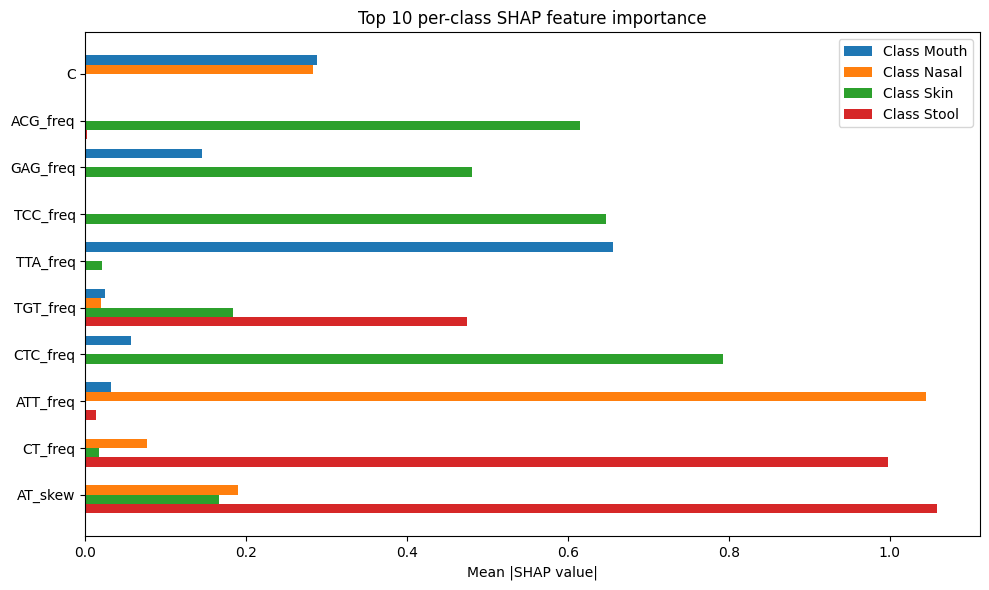

In [26]:
# Use the last trained model or an ensemble
explainer = shap.TreeExplainer(models[-1])   # take the last fold model
# or you could ensemble shap values from multiple folds if you want

shap_values = explainer.shap_values(X)

# SHAP values from explainer
shap_values = explainer.shap_values(X)  # list of arrays, one per class

if isinstance(shap_values, list):
    n_classes = len(shap_values)
    class_names = le.inverse_transform(np.arange(n_classes))  # use label encoder if available
    
    # Per-class mean |SHAP|
    mean_abs_shap = [np.abs(sv).mean(axis=0) for sv in shap_values]
    
    # Rank features by overall importance (average across classes)
    overall_importance = np.mean(mean_abs_shap, axis=0)
    top_idx = np.argsort(overall_importance)[-10:]  # top 10
    top_features = X.columns[top_idx]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ind = np.arange(len(top_idx))  # only top features
    width = 0.8 / n_classes
    
    for i, class_name in enumerate(class_names):
        ax.barh(
            ind + i * width,
            mean_abs_shap[i][top_idx],
            height=width,
            label=f"Class {class_name}"
        )
    
    ax.set_yticks(ind + width * (n_classes - 1) / 2)
    ax.set_yticklabels(top_features)
    ax.invert_yaxis()
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title("Top 10 per-class SHAP feature importance")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Binary classification detected — use regular shap.summary_plot instead.")

In [27]:
if isinstance(shap_values, list):  
    # Take mean absolute SHAP values across classes
    shap_values_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
else:  
    # Binary classification → shap_values is already an array
    shap_values_mean = shap_values

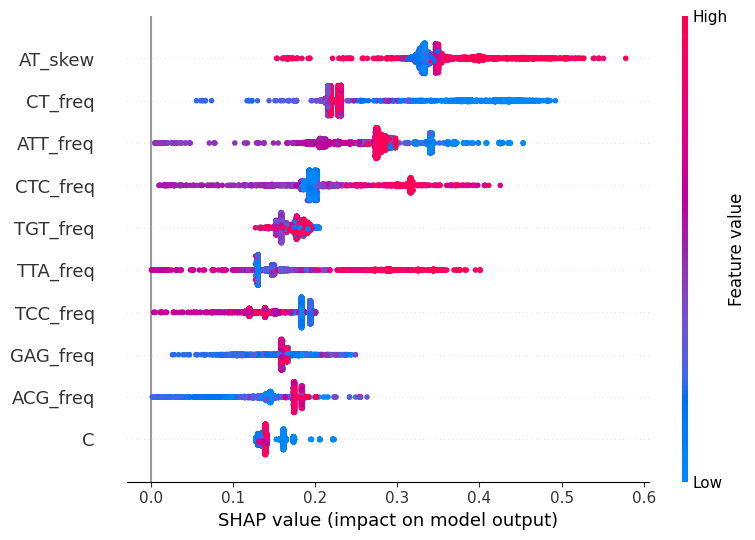

In [28]:
shap.summary_plot(shap_values_mean, X, max_display=10)

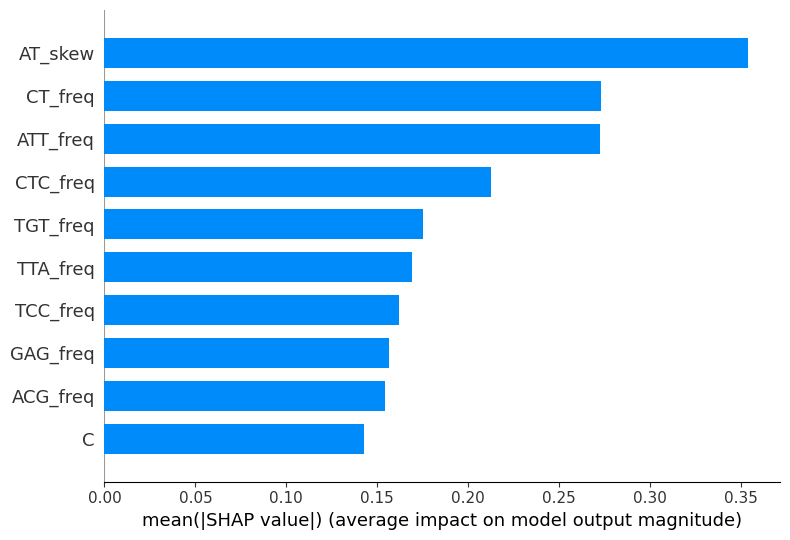

In [29]:
# Summary plot (mean |SHAP| values per feature)
shap.summary_plot(shap_values_mean, X, plot_type="bar", max_display=10)

=== SHAP values for class Mouth ===


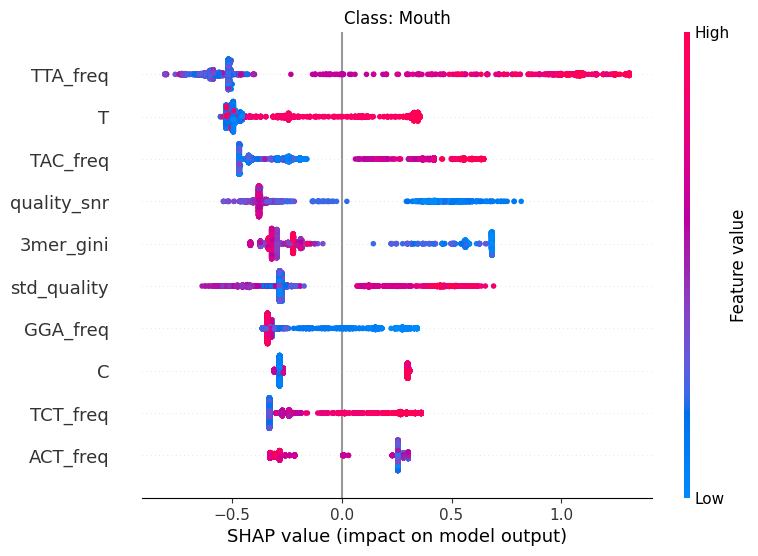

=== SHAP values for class Nasal ===


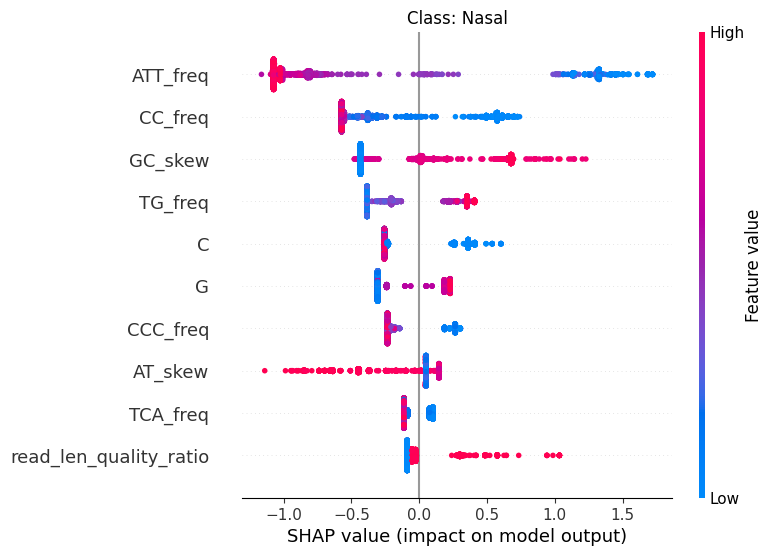

=== SHAP values for class Skin ===


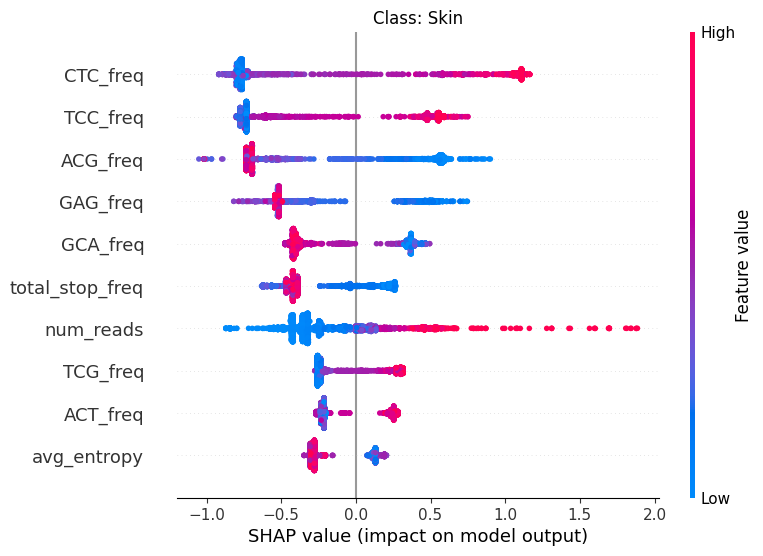

=== SHAP values for class Stool ===


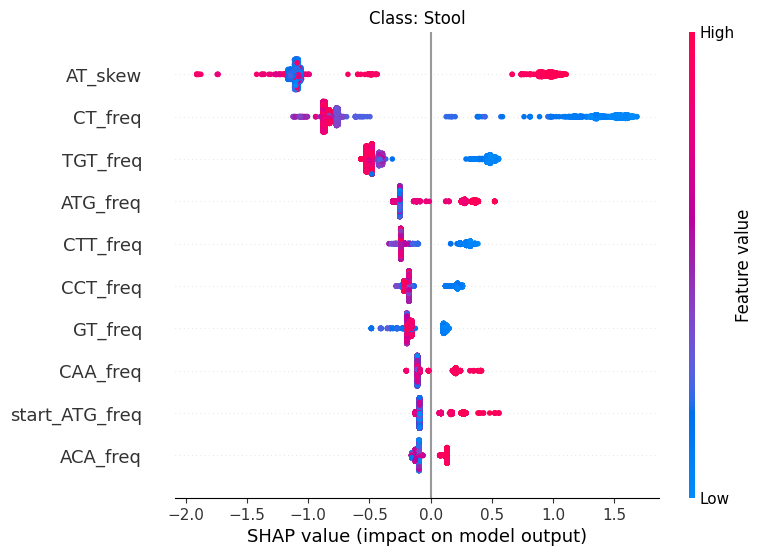

In [30]:
for class_idx, class_name in enumerate(le.classes_):
    print(f"=== SHAP values for class {class_name} ===")
    shap.summary_plot(shap_values[class_idx], X, max_display=10, show=False)
    plt.title(f"Class: {class_name}")
    plt.show()

# Inference

In [ ]:
# Predict
X_test = df_test[use_cols]
dtest = xgb.DMatrix(X_test)  # ✅ Wrap test set in DMatrix

n_classes = len(np.unique(y))
proba_product = np.ones((len(X_test), n_classes))

for model in models:
    preds = model.predict(dtest)  # ✅ Use DMatrix instead of raw DataFrame
    proba_product *= preds  

# Ensemble: Averaged probabilities from different models
pred_proba = proba_product ** (1 / len(models))
pred_proba = pred_proba / pred_proba.sum(axis=1, keepdims=True)
y_new_pred = np.argmax(pred_proba, axis=1)

# Create output DataFrame
y_new_pred_labels = le.inverse_transform(y_new_pred)
print(y_new_pred_labels[:10])  # first 10 predicted classes

class_labels = le.inverse_transform(np.arange(n_classes))
probs_df = pd.DataFrame(pred_proba, columns=class_labels)  # class labels as column names
probs_df.insert(0, "filename", df_test["filename"])
probs_df["filename"] = probs_df["filename"].str.replace(".fastq", "", regex=False)

# Save to CSV
probs_df.to_csv("centralized.csv", index=False)
probs_df.head()

['Nasal' 'Nasal' 'Mouth' 'Mouth' 'Mouth' 'Skin' 'Stool' 'Stool' 'Stool'
 'Mouth']


,filename,Mouth,Nasal,Skin,Stool
0,ID_ABHFUP,0.000062,0.999490,0.000047,0.000401
1,ID_ADBLNY,0.000057,0.999612,0.000038,0.000293
2,ID_AFAEMB,0.992092,0.000276,0.007396,0.000237
3,ID_AFBBWK,0.999795,0.000036,0.000139,0.000030
4,ID_AGHEZK,0.998926,0.000133,0.000824,0.000117


# End